In [1]:
file_read = "004_fit_MPAA"
file_write = "005_RMSE_MPAA"

In [2]:
import polars as pl

df_train_val_preds = pl.read_parquet(f"{file_read}_train_val_preds.parquet")
df_test_preds = pl.read_parquet(f"{file_read}_test_preds.parquet")
df_coefs = pl.read_parquet(f"{file_read}_coefs.parquet")

In [3]:
column_target = "beta_av"
column_target_scaled = "beta_av_logit"
column_pred = f"{column_target}_pred"
column_pred_scaled = f"{column_target_scaled}_pred"

In [4]:
df_train_val_preds = df_train_val_preds.with_columns(
    (100 / (1 + (-pl.col(column_target_scaled)).exp())).alias(column_target),
    (100 / (1 + (-pl.col(column_pred_scaled)).exp())).alias(column_pred),
)

In [5]:
df_train_val_preds

backbone_test,n_features,backbone,pyridone,beta_av_logit,beta_av_logit_pred,beta_av,beta_av_pred
i32,i32,i64,i64,f64,f64,f64,f64
0,86,1,0,0.061619,-0.065424,51.539999,48.364972
0,86,2,0,-0.086761,-0.130881,47.832328,46.732637
0,86,3,0,-0.086245,-0.108648,47.845209,47.286479
0,86,4,0,-0.242775,-0.117323,43.960253,47.070288
0,86,5,0,0.146419,0.109867,53.653941,52.743917
…,…,…,…,…,…,…,…
20,5,2,12,-0.175969,-0.157502,45.612098,46.070566
20,5,3,12,-0.155744,-0.157502,46.114252,46.070566
20,5,4,12,-0.010116,-0.157502,49.74711,46.070566


In [6]:
df_train_val_rmse = (
    df_train_val_preds
    .group_by("n_features", maintain_order=True)
    .agg(
        (pl.col(column_target) - pl.col(column_pred)).pow(2).mean().sqrt()
        .alias(f"{column_target}_rmse")
    )
)

In [7]:
df_train_val_rmse

n_features,beta_av_rmse
i32,f64
86,4.522149
85,4.522149
84,4.522149
83,4.522149
82,4.521929
…,…
9,4.241572
8,4.305324
7,4.451461


In [8]:
df_train_val_rmse_min = df_train_val_rmse.filter(
    pl.col(f"{column_target}_rmse") == pl.col(f"{column_target}_rmse").min()
)

In [9]:
df_train_val_rmse_min

n_features,beta_av_rmse
i32,f64
44,3.952137


In [10]:
n_features_min = df_train_val_rmse_min["n_features"][0]

In [11]:
df_test_preds = df_test_preds.with_columns(
    (100 / (1 + (-pl.col(column_target_scaled)).exp())).alias(column_target),
    (100 / (1 + (-pl.col(column_pred_scaled)).exp())).alias(column_pred),
)

In [12]:
df_test_preds

backbone_test,n_features,pyridone,beta_av_logit,beta_av_logit_pred,beta_av,beta_av_pred
i32,i32,i64,f64,f64,f64,f64
0,86,0,0.055549,0.510594,51.388357,62.494561
0,86,1,0.56851,1.123783,63.841924,75.46897
0,86,2,0.367487,0.989765,59.085161,72.904156
0,86,3,0.122542,0.932066,53.059721,71.749434
0,86,4,0.157034,0.711304,53.917807,67.068917
…,…,…,…,…,…,…
20,5,8,-1.435257,-0.220913,19.228094,44.49953
20,5,9,-1.120282,-0.122029,24.595903,46.953062
20,5,10,-1.321297,-0.162302,21.060263,45.951325


In [13]:
df_test_rmse = (
    df_test_preds
    .group_by("n_features", maintain_order=True)
    .agg(
        (pl.col(column_target) - pl.col(column_pred)).pow(2).mean().sqrt()
        .alias(f"{column_target}_rmse")
    )
)

In [14]:
df_test_rmse

n_features,beta_av_rmse
i32,f64
86,12.992339
85,12.992339
84,12.992339
83,12.992339
82,12.994397
…,…
9,14.768906
8,15.922375
7,15.694878


In [15]:
df_test_rmse_min = df_test_rmse.filter(pl.col("n_features") == n_features_min)

In [16]:
df_test_rmse_min

n_features,beta_av_rmse
i32,f64
44,11.905044


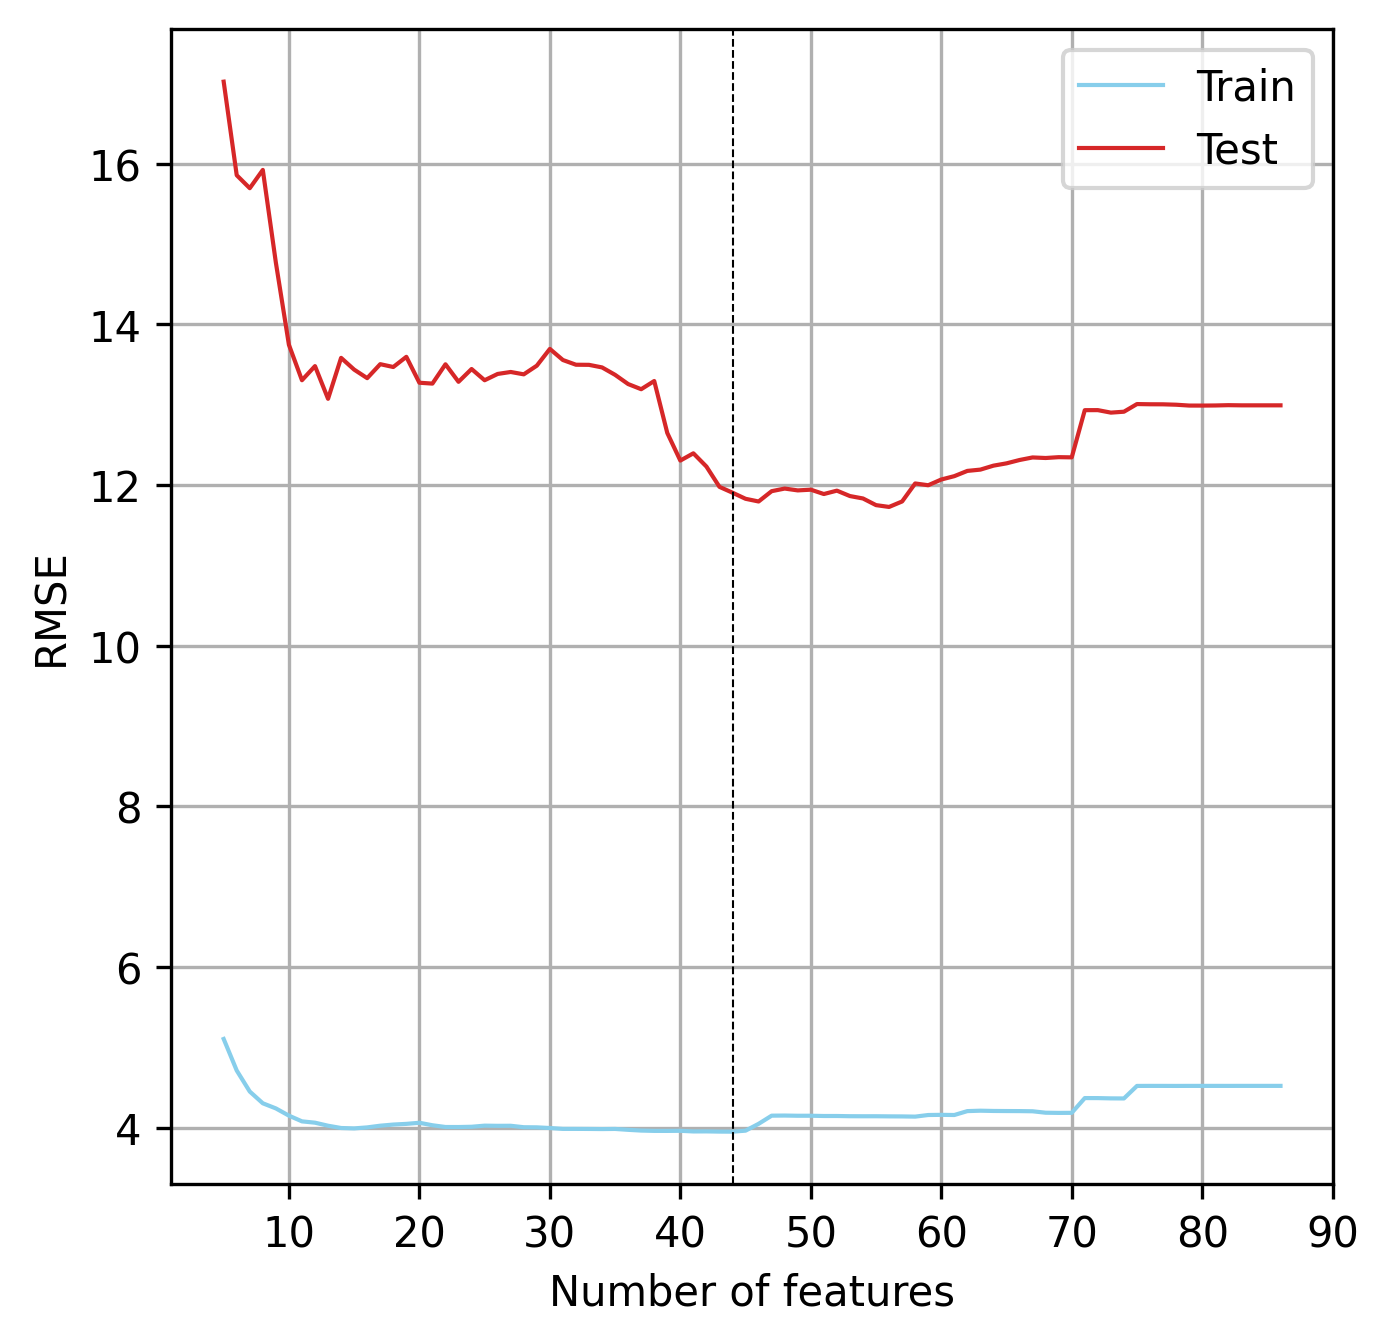

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 5), dpi=300)

ax.plot(
    df_train_val_rmse["n_features"],
    df_train_val_rmse[f"{column_target}_rmse"],
    c="skyblue",
    label="Train",
    lw=1
)
ax.plot(
    df_test_rmse["n_features"],
    df_test_rmse[f"{column_target}_rmse"],
    c="tab:red",
    label="Test",
    lw=1
)
ax.axvline(
    n_features_min,
    c="black",
    lw=0.5,
    ls="--"
)

ax.set_xlabel("Number of features")
ax.set_ylabel("RMSE")

ax.grid()
ax.legend()

plt.savefig(
    f"{file_write}_plot.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()

In [18]:
df_train_val_min = df_train_val_preds.filter(pl.col("n_features") == n_features_min)

In [19]:
df_train_val_min

backbone_test,n_features,backbone,pyridone,beta_av_logit,beta_av_logit_pred,beta_av,beta_av_pred
i32,i32,i64,i64,f64,f64,f64,f64
0,44,1,0,0.061619,-0.065427,51.539999,48.364904
0,44,2,0,-0.086761,-0.130883,47.832328,46.732588
0,44,3,0,-0.086245,-0.108645,47.845209,47.286554
0,44,4,0,-0.242775,-0.117331,43.960253,47.070084
0,44,5,0,0.146419,0.109868,53.653941,52.743934
…,…,…,…,…,…,…,…
20,44,2,12,-0.175969,-0.195571,45.612098,45.126243
20,44,3,12,-0.155744,-0.17641,46.114252,45.60114
20,44,4,12,-0.010116,-0.180534,49.74711,45.498868


In [20]:
df_test_min = df_test_preds.filter(pl.col("n_features") == n_features_min)

In [21]:
df_test_min

backbone_test,n_features,pyridone,beta_av_logit,beta_av_logit_pred,beta_av,beta_av_pred
i32,i32,i64,f64,f64,f64,f64
0,44,0,0.055549,0.477357,51.388357,61.712363
0,44,1,0.56851,1.090542,63.841924,74.848381
0,44,2,0.367487,0.956533,59.085161,72.242717
0,44,3,0.122542,0.898832,53.059721,71.070934
0,44,4,0.157034,0.678063,53.917807,66.330625
…,…,…,…,…,…,…
20,44,8,-1.435257,-0.227982,19.228094,44.325001
20,44,9,-1.120282,-0.168805,24.595903,45.789862
20,44,10,-1.321297,-0.229562,21.060263,44.286029


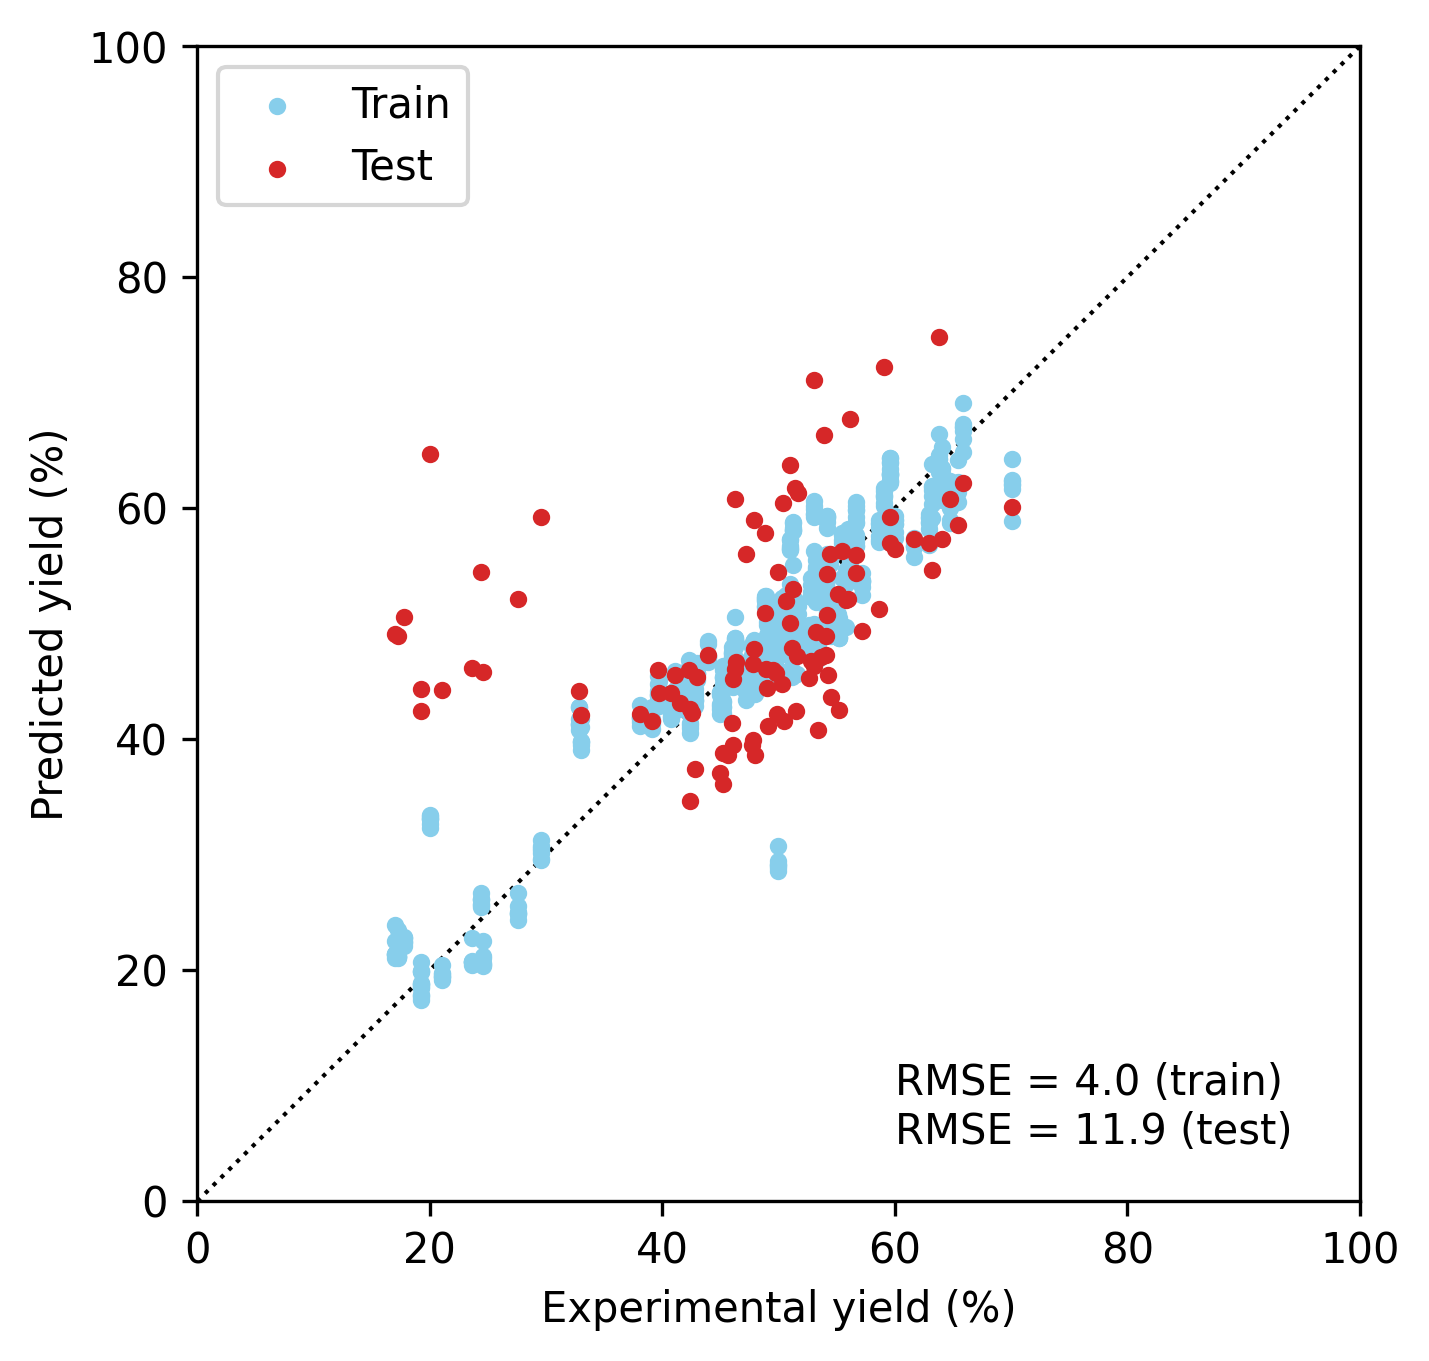

In [22]:
fig, ax = plt.subplots(figsize=(5, 5), dpi=300)

ax.plot(
    [0, 100],
    [0, 100],
    c="black",
    linestyle="dotted",
    lw=1,
    zorder=0
)
ax.scatter(
    df_train_val_min[column_target],
    df_train_val_min[column_pred],
    c="skyblue",
    label="Train",
    s=10,
    zorder=1
)
ax.scatter(
    df_test_min[column_target],
    df_test_min[column_pred],
    c="tab:red",
    label="Test",
    s=10,
    zorder=2
)

ax.set_xlabel("Experimental yield (%)")
ax.set_ylabel("Predicted yield (%)")
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

ax.legend()
ax.text(
    0.60, 0.05,
    f"RMSE = {df_train_val_rmse_min[f'{column_target}_rmse'][0]:1.1f} (train)\n"
    f"RMSE = {df_test_rmse_min[f'{column_target}_rmse'][0]:1.1f} (test)",
    transform=ax.transAxes
)

plt.savefig(
    f"{file_write}_scatter_all.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()

In [23]:
column_group = "backbone"

In [24]:
groups_test = df_test_preds[f"{column_group}_test"].unique(maintain_order=True)

In [25]:
groups_test

backbone_test
i32
0
1
2
3
4
5
19
20


In [26]:
df_train_val_min

backbone_test,n_features,backbone,pyridone,beta_av_logit,beta_av_logit_pred,beta_av,beta_av_pred
i32,i32,i64,i64,f64,f64,f64,f64
0,44,1,0,0.061619,-0.065427,51.539999,48.364904
0,44,2,0,-0.086761,-0.130883,47.832328,46.732588
0,44,3,0,-0.086245,-0.108645,47.845209,47.286554
0,44,4,0,-0.242775,-0.117331,43.960253,47.070084
0,44,5,0,0.146419,0.109868,53.653941,52.743934
…,…,…,…,…,…,…,…
20,44,2,12,-0.175969,-0.195571,45.612098,45.126243
20,44,3,12,-0.155744,-0.17641,46.114252,45.60114
20,44,4,12,-0.010116,-0.180534,49.74711,45.498868


In [27]:
df_train_val_min_rmse = (
    df_train_val_min
    .group_by(f"{column_group}_test", maintain_order=True)
    .agg(
        (pl.col(column_target) - pl.col(column_pred)).pow(2).mean().sqrt()
        .alias(f"{column_target}_rmse")
    )
)

In [28]:
df_train_val_min_rmse

backbone_test,beta_av_rmse
i32,f64
0,4.113903
1,4.093997
2,4.165032
3,4.055197
4,4.357158
5,3.953809
19,3.834091
20,2.85662


In [29]:
df_test_min_rmse = (
    df_test_min
    .group_by(f"{column_group}_test", maintain_order=True)
    .agg(
        (pl.col(column_target) - pl.col(column_pred)).pow(2).mean().sqrt()
        .alias(f"{column_target}_rmse")
    )
)

In [30]:
df_test_min_rmse

backbone_test,beta_av_rmse
i32,f64
0,11.977907
1,6.601947
2,7.202887
3,4.15021
4,4.084522
5,7.061847
19,5.25409
20,27.991432


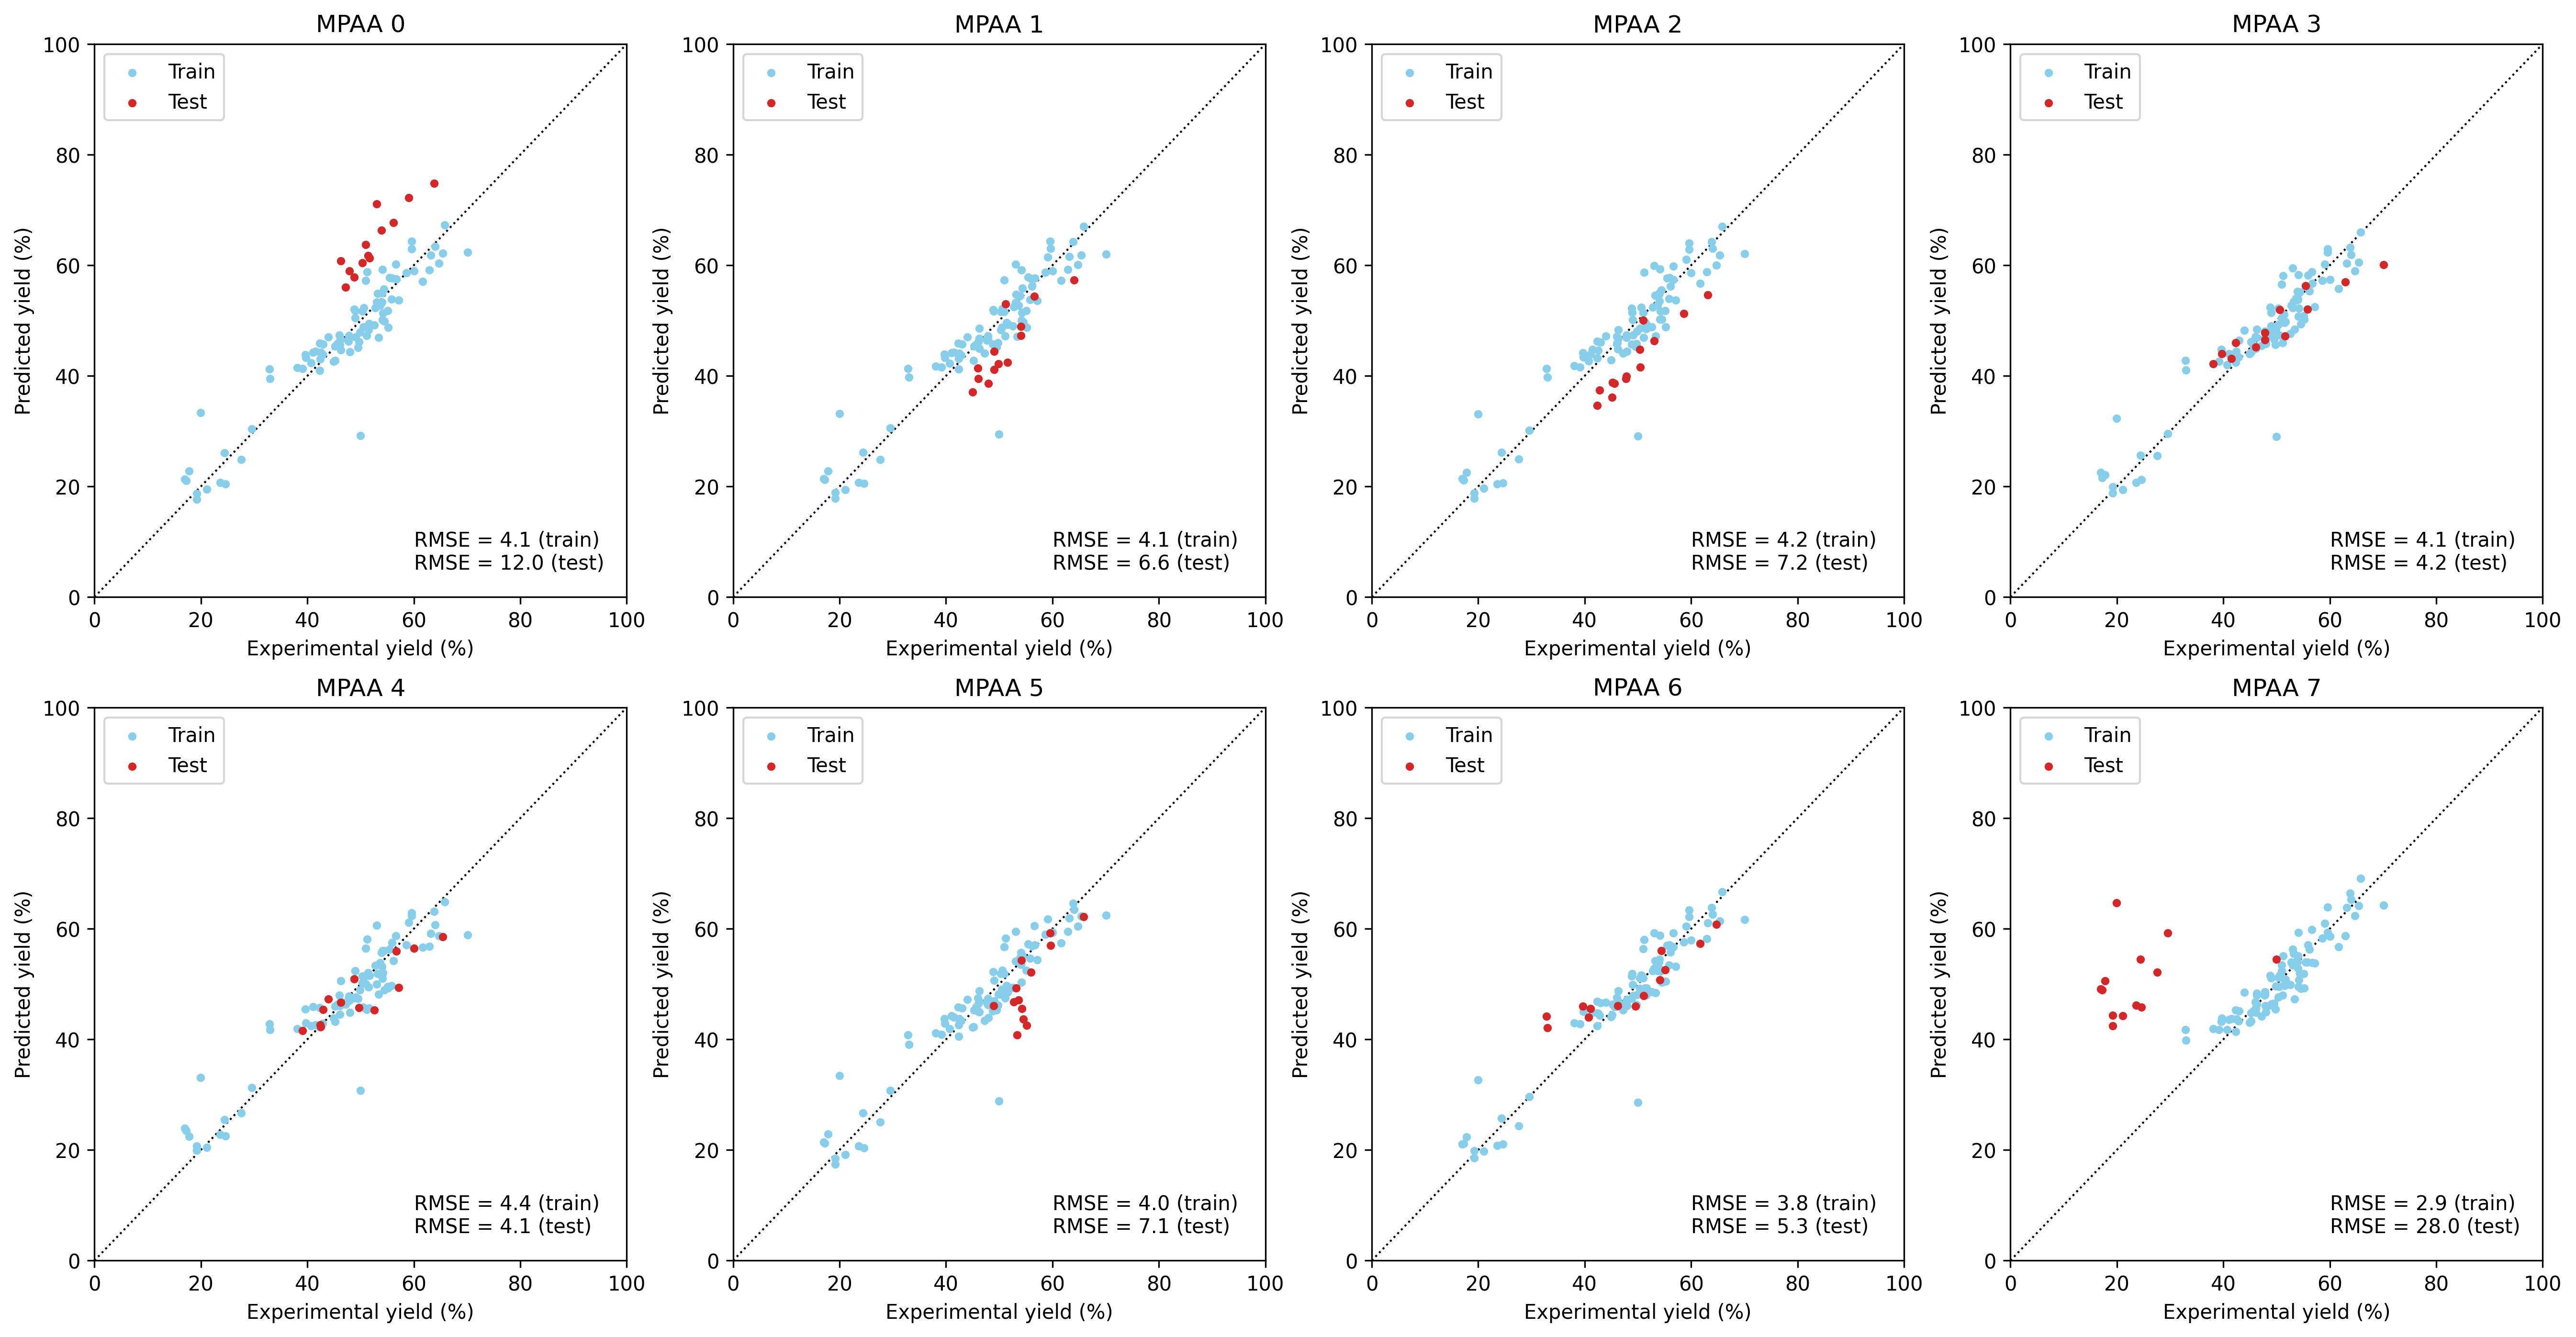

In [31]:
fig, axes = plt.subplots(2, 4, figsize=(22, 11), dpi=300)

for group_test in groups_test:
    df_train_val_min_ = df_train_val_min.filter(pl.col(f'{column_group}_test') == group_test)
    df_test_min_ = df_test_min.filter(pl.col(f'{column_group}_test') == group_test)
    df_train_val_min_rmse_ = df_train_val_min_rmse.filter(pl.col(f'{column_group}_test') == group_test)
    df_test_min_rmse_ = df_test_min_rmse.filter(pl.col(f'{column_group}_test') == group_test)
    
    if group_test == 19:
        group_test = 6
    elif group_test == 20:
        group_test = 7
    
    div, mod = divmod(group_test, 4)
    
    axes[div, mod].plot(
        [0, 100],
        [0, 100],
        c="black",
        linestyle="dotted",
        lw=1,
        zorder=0
    )
    axes[div, mod].scatter(
        df_train_val_min_[column_target],
        df_train_val_min_[column_pred],
        c="skyblue",
        s=10,
        label="Train",
        zorder=1
    )
    axes[div, mod].scatter(
        df_test_min_[column_target],
        df_test_min_[column_pred],
        c="tab:red",
        s=10,
        label="Test",
        zorder=2
    )
    
    axes[div, mod].set_title(f"MPAA {group_test}")
    axes[div, mod].set_xlabel("Experimental yield (%)")
    axes[div, mod].set_ylabel("Predicted yield (%)")
    axes[div, mod].set_xlim(0, 100)
    axes[div, mod].set_ylim(0, 100)
    
    axes[div, mod].legend()
    axes[div, mod].text(
        0.60, 0.05,
        f"RMSE = {df_train_val_min_rmse_[f'{column_target}_rmse'][0]:1.1f} (train)\n"
        f"RMSE = {df_test_min_rmse_[f'{column_target}_rmse'][0]:1.1f} (test)",
        transform=axes[div, mod].transAxes
    )
    
plt.savefig(
    f"{file_write}_scatter_each.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()